# Regression Track — Exploratory Data Analysis

## Dataset

The dataset used for the regression track is the Metro Interstate 
Traffic Volume dataset obtained from the UCI Machine Learning Repository.

The objective is to predict hourly westbound I-94 traffic volume using 
weather, holiday and temporal information.

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot settings
sns.set_theme(style="whitegrid")

In [4]:
# If required, install the UCI repository package
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch dataset from UCI
dataset = fetch_ucirepo(id=492)

# Separate features and target
X = dataset.data.features
y = dataset.data.targets

# Combine them into one DataFrame for EDA
df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [6]:
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


<h2>Dataset Loading & Audit</h2>

In [7]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 48204
Number of columns: 9
Dataset shape: (48204, 9)


In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [9]:
# data types 

print("Data Types:\n")
print(df.dtypes)

Data Types:

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [10]:
# Basic statistical information for numerical columns

df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [11]:
# Number of unique values in each column

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

holiday: 11 unique values
temp: 5843 unique values
rain_1h: 372 unique values
snow_1h: 12 unique values
clouds_all: 60 unique values
weather_main: 11 unique values
weather_description: 38 unique values
date_time: 40575 unique values
traffic_volume: 6704 unique values


In [12]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [13]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [14]:
# Target variable

target = 'traffic_volume'

print("Target variable:", target)
print("\nTarget statistics:\n")
print(df[target].describe())

Target variable: traffic_volume

Target statistics:

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


In [15]:
# Target summary statistics

print("Mean traffic volume:", df[target].mean())
print("Median traffic volume:", df[target].median())
print("Minimum traffic volume:", df[target].min())
print("Maximum traffic volume:", df[target].max())
print("Standard deviation:", df[target].std())

Mean traffic volume: 3259.8183553232097
Median traffic volume: 3380.0
Minimum traffic volume: 0
Maximum traffic volume: 7280
Standard deviation: 1986.8606704463552


<h2>Feature Distributions</h2>

In [16]:
# Defined feature groups

numeric_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all'
]

categorical_features = [
    'holiday',
    'weather_main',
    'weather_description'
]

date_feature = 'date_time'

target = 'traffic_volume'

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nDate/time feature:")
print(date_feature)

print("\nTarget:")
print(target)

Numerical features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all']

Categorical features:
['holiday', 'weather_main', 'weather_description']

Date/time feature:
date_time

Target:
traffic_volume


In [17]:
# Convert date_time to datetime format

df['date_time'] = pd.to_datetime(df['date_time'])

print(df['date_time'].dtype)

datetime64[ns]


In [18]:
# Time period covered by the dataset

print("Start date:", df['date_time'].min())
print("End date:", df['date_time'].max())

Start date: 2012-10-02 09:00:00
End date: 2018-09-30 23:00:00


<h3>Numerical Feature Visualisations</h3>

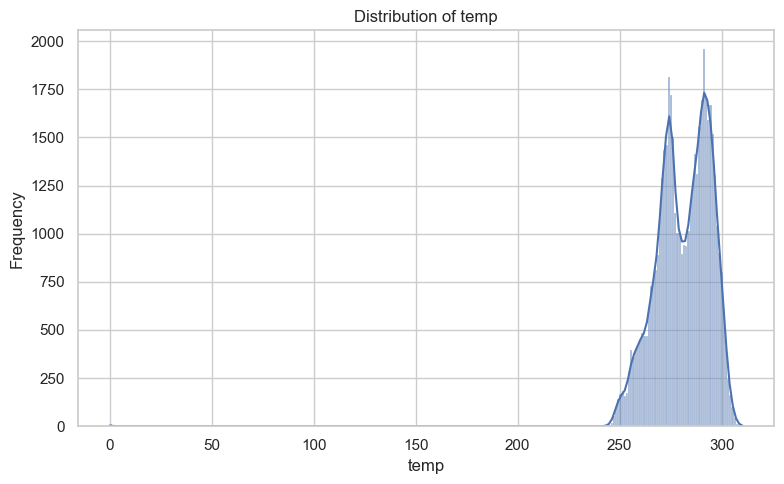

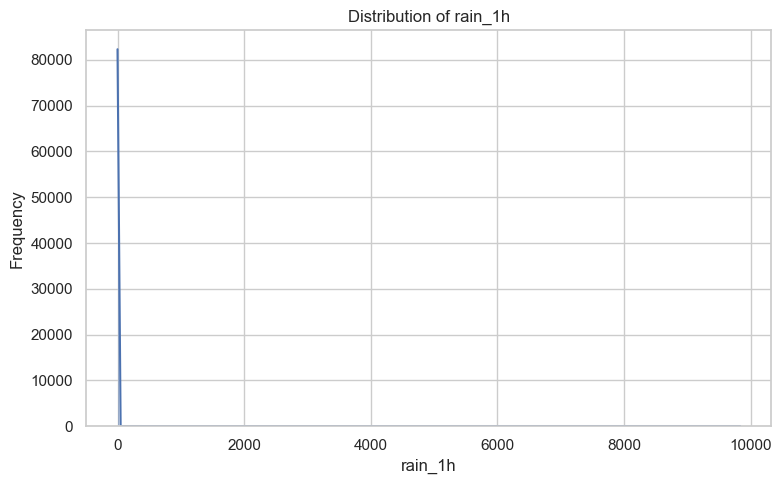

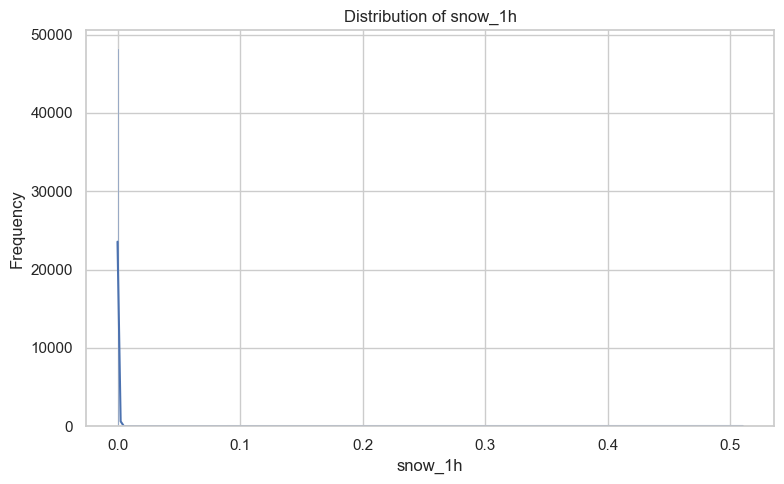

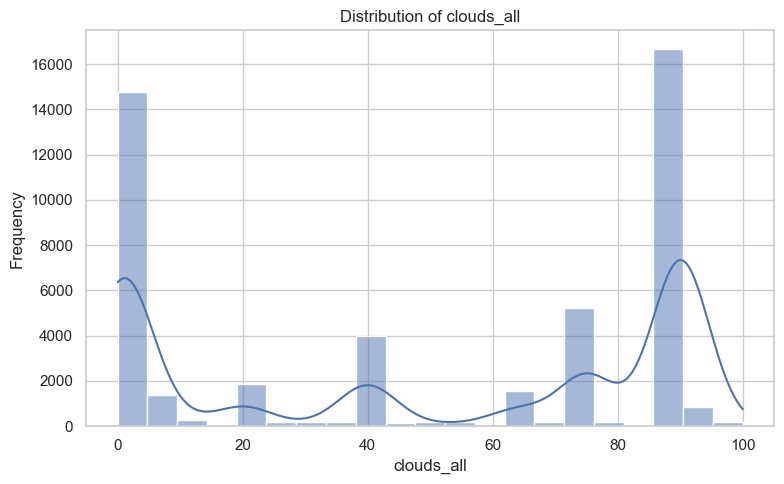

In [19]:
# Distribution plots for numerical features

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(data=df, x=feature, kde=True)
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Observation — Numerical Feature Distributions

The numerical features show different distribution patterns and ranges. 
Temperature has a continuous distribution, while rainfall and snowfall 
contain many observations at or near zero. Cloud coverage is bounded 
between 0% and 100%.

The differences in scale and distribution indicate that preprocessing 
and scaling may be important for some of the regression algorithms, 
particularly distance-based and kernel-based models.

<h3>Categorical Feature Visualisations</h3>

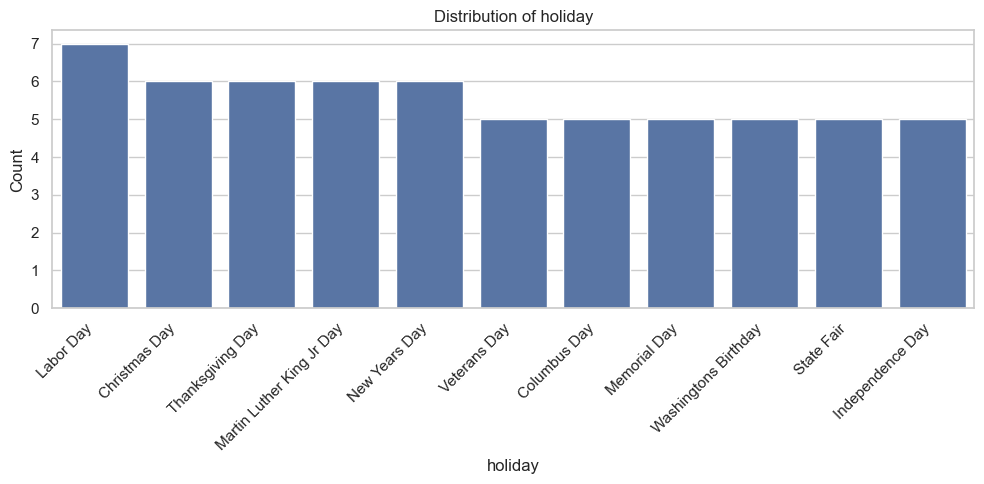

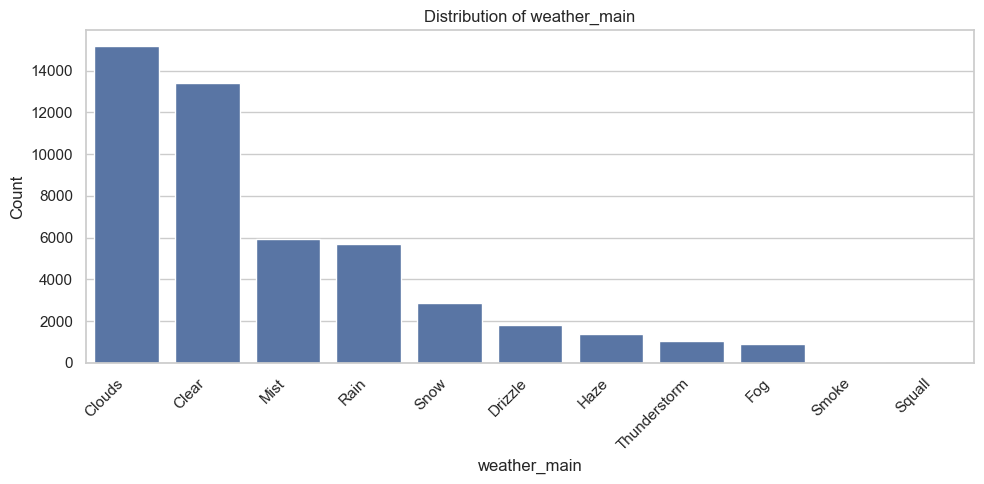

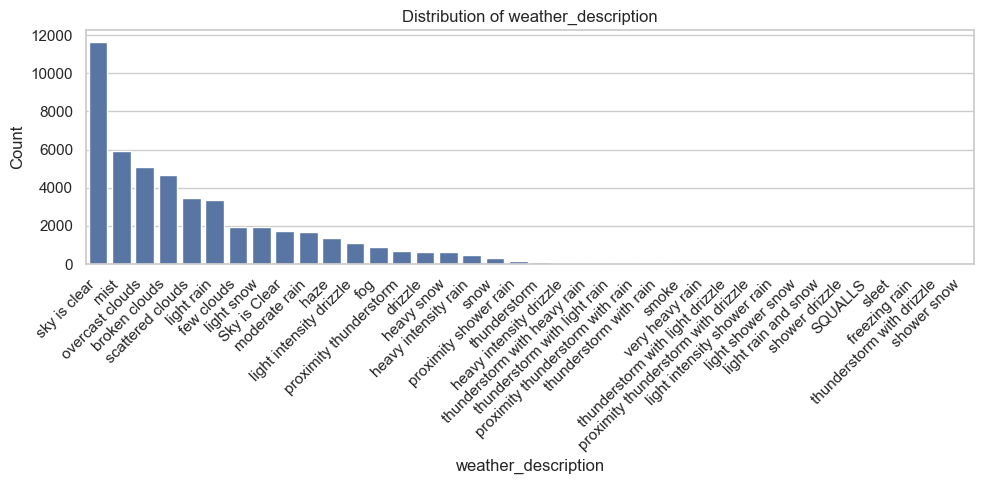

In [20]:
# Distribution plots for categorical features

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    
    order = df[feature].value_counts().index
    
    sns.countplot(
        data=df,
        x=feature,
        order=order
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

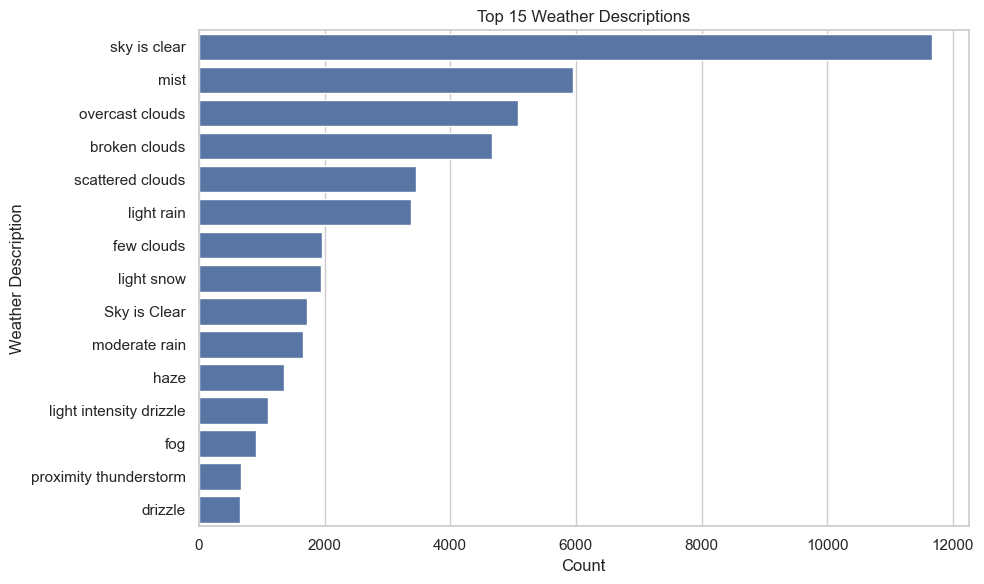

In [21]:
# Top weather descriptions

top_weather = df['weather_description'].value_counts().head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title('Top 15 Weather Descriptions')
plt.xlabel('Count')
plt.ylabel('Weather Description')
plt.tight_layout()
plt.show()

<h3>DateTime Visualisations</h3>

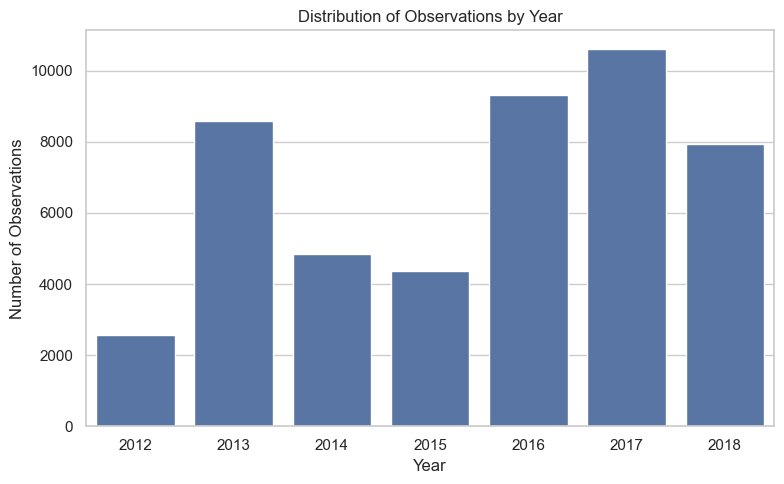

In [22]:
# Extract year for temporal EDA

df['year'] = df['date_time'].dt.year

year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title('Distribution of Observations by Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

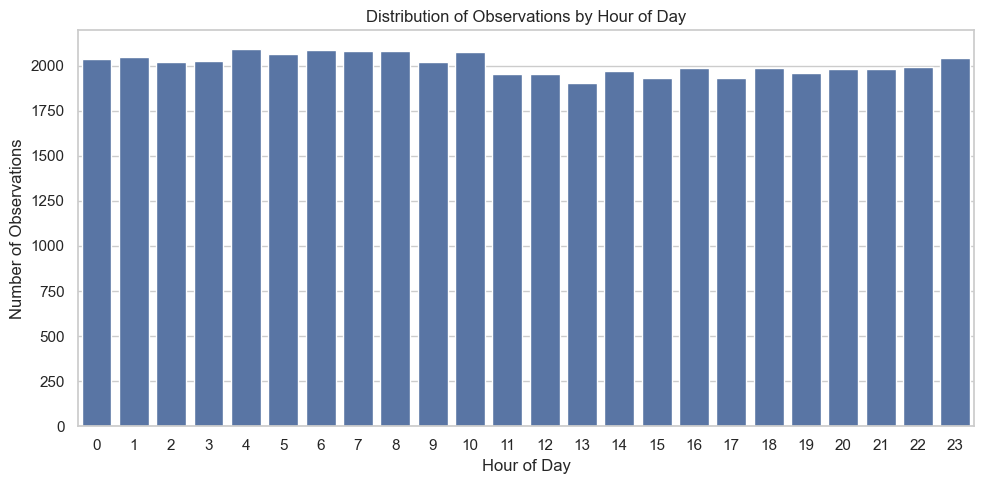

In [23]:
# Extract hour from date_time

df['hour'] = df['date_time'].dt.hour

hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values
)

plt.title('Distribution of Observations by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

<h2>Target Distribution Visualisation</h2>

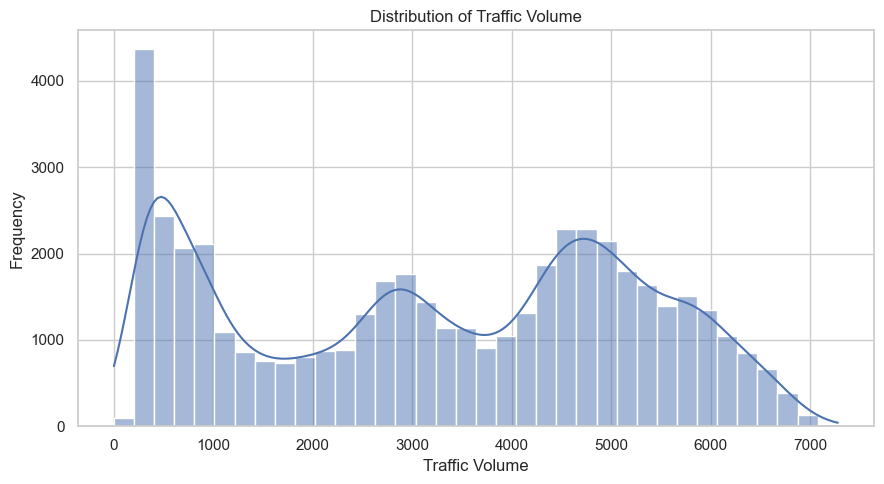

In [24]:
# Distribution of target variable

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='traffic_volume',
    kde=True
)

plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

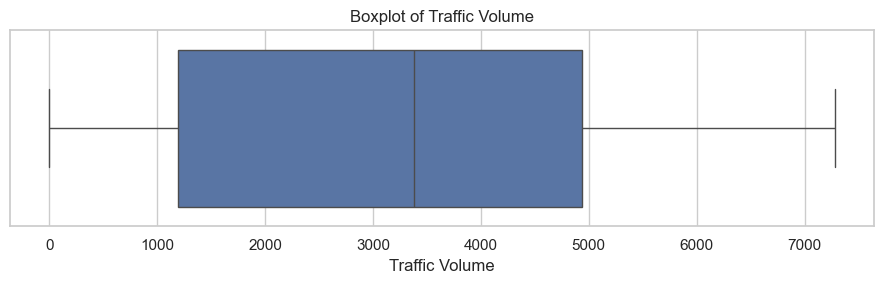

In [25]:
# Boxplot of target variable

plt.figure(figsize=(9, 3))

sns.boxplot(
    x=df['traffic_volume']
)

plt.title('Boxplot of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.tight_layout()
plt.show()

### Observation — Target Distribution

The target variable, traffic_volume, shows the distribution of hourly 
traffic volume observations. The distribution indicates the range of 
traffic volumes observed on I-94 and allows us to assess whether the 
target is approximately symmetric or skewed.

The presence of observations at substantially different traffic-volume 
levels suggests that the regression models will need to learn varying 
traffic conditions rather than predicting a single typical traffic level.

<h2>Correlation Visualisations</h2>

In [26]:
# Select numerical columns including the target

correlation_columns = numeric_features + ['traffic_volume']

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
temp,1.000000,0.009069,-0.019755,-0.101976,0.130299
rain_1h,0.009069,1.000000,-0.000090,0.004818,0.004714
snow_1h,-0.019755,-0.000090,1.000000,0.027931,0.000733
clouds_all,-0.101976,0.004818,0.027931,1.000000,0.067054
traffic_volume,0.130299,0.004714,0.000733,0.067054,1.000000


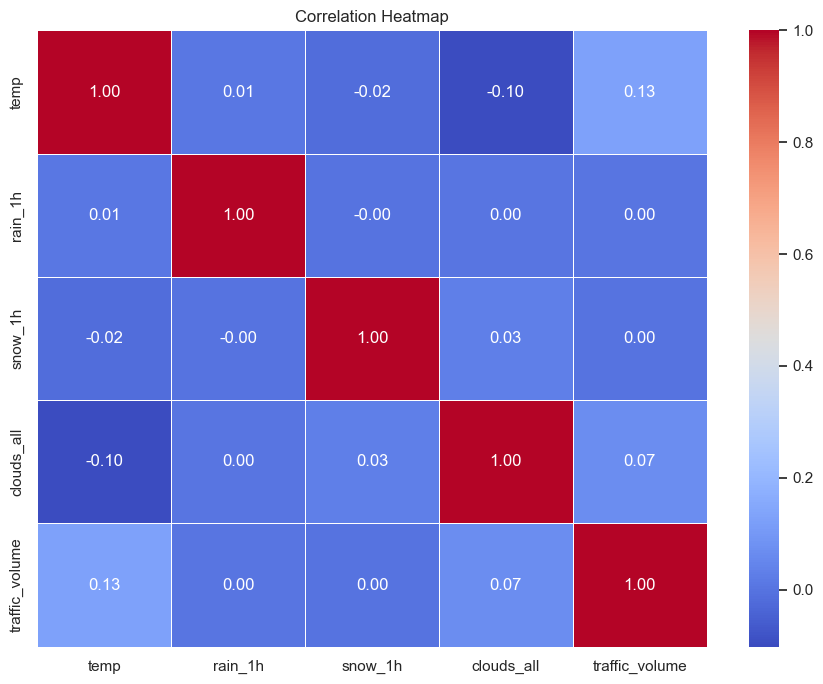

In [27]:
# Correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation — Correlation Heatmap

The correlation heatmap shows the pairwise linear relationships between 
the numerical features and the target variable, traffic_volume.

The strength and direction of each relationship can be compared using 
the correlation coefficients. Features with larger absolute correlation 
values with traffic_volume show stronger linear association with the 
target, while values close to zero indicate weaker linear association.

Correlation should not be interpreted as evidence of causation.

<h3>Feature-Target Relationship</h3>

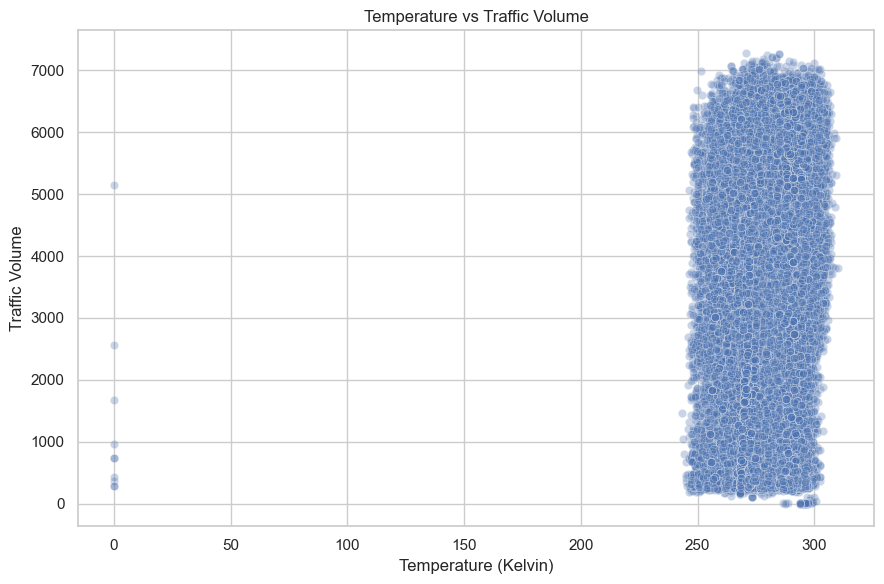

In [28]:
# Scatter plot: Temperature vs Traffic Volume

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='temp',
    y='traffic_volume',
    alpha=0.3
)

plt.title('Temperature vs Traffic Volume')
plt.xlabel('Temperature (Kelvin)')
plt.ylabel('Traffic Volume')
plt.tight_layout()
plt.show()

### Observation — Temperature vs Traffic Volume

The scatter plot shows how traffic_volume varies with temperature.

The points are widely distributed across the temperature range, 
indicating that temperature alone does not completely determine 
traffic volume. Any visible upward, downward, or nonlinear pattern 
should be considered when selecting and comparing regression models.

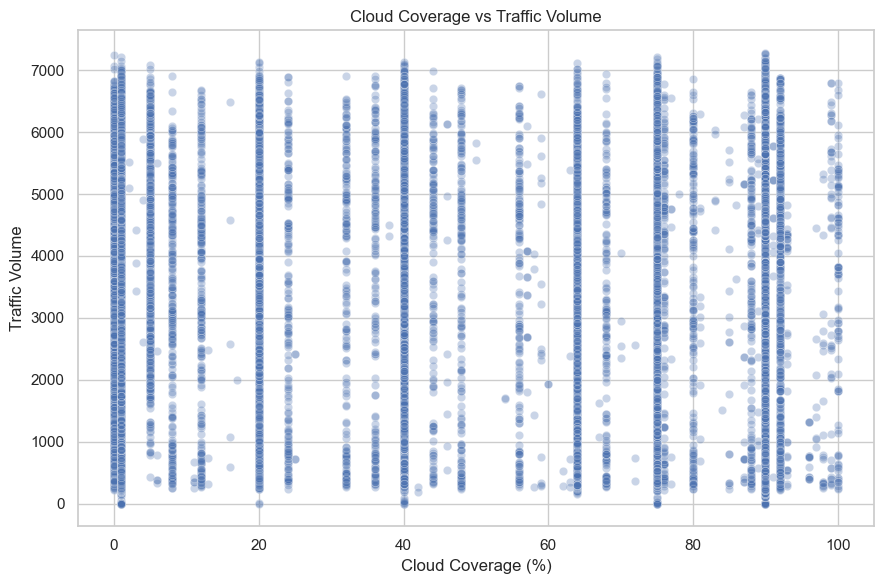

In [29]:
# Scatter plot: Cloud Coverage vs Traffic Volume

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='clouds_all',
    y='traffic_volume',
    alpha=0.3
)

plt.title('Cloud Coverage vs Traffic Volume')
plt.xlabel('Cloud Coverage (%)')
plt.ylabel('Traffic Volume')
plt.tight_layout()
plt.show()

### Observation — Cloud Coverage vs Traffic Volume

The scatter plot shows the relationship between cloud coverage and 
traffic_volume.

The observations are distributed across different cloud-coverage 
levels, allowing us to determine whether a clear linear relationship 
exists between the two variables. The amount of scatter indicates how 
much variation in traffic volume remains unexplained by cloud coverage 
alone.

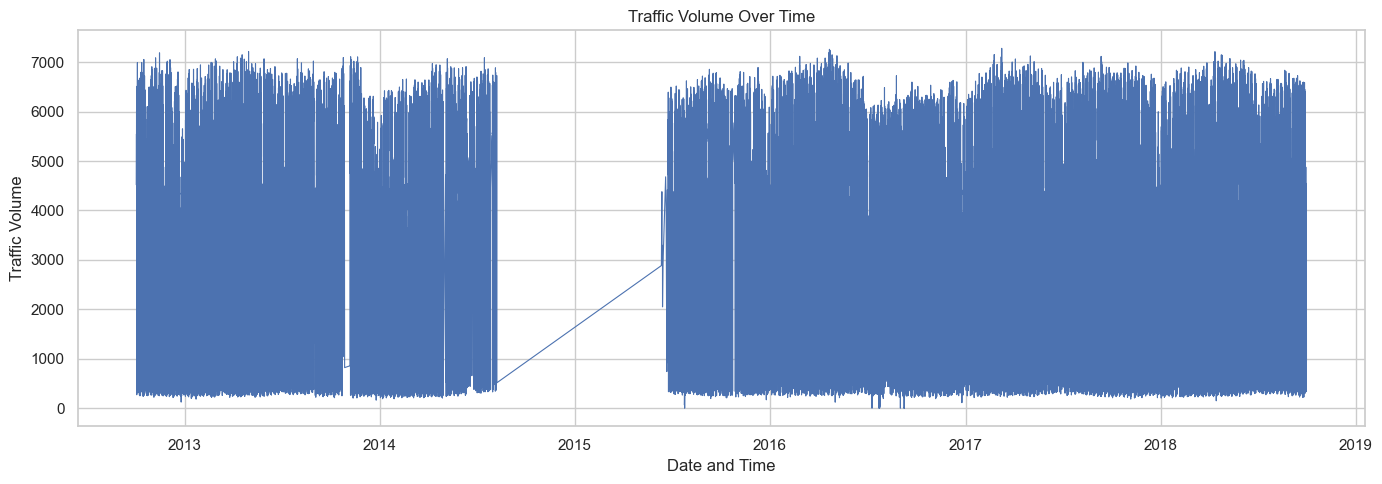

In [30]:
# Traffic volume over time

plt.figure(figsize=(14, 5))

plt.plot(
    df['date_time'],
    df['traffic_volume'],
    linewidth=0.8
)

plt.title('Traffic Volume Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Traffic Volume')
plt.tight_layout()
plt.show()

### Observation — Traffic Volume by Hour

The average traffic volume varies across the hours of the day rather 
than remaining constant.

This indicates that the time of day is an important factor associated 
with traffic volume. Since date_time contains temporal information, 
extracting useful time-based features such as hour, day of week, month, 
or year may help the regression models capture recurring traffic 
patterns.

### Observation — Data Quality Audit

The dataset audit was performed for missing values and duplicate rows.

According to the UCI documentation, the dataset contains no missing 
values. The notebook independently verifies the missing-value counts 
for every column.

Duplicate rows were also checked so that duplicate observations do not 
artificially influence the regression models.

<h2>Final EDA Summary</h2>

In [31]:
# Final EDA summary

print("===== DATASET SUMMARY =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Target:", target)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== NUMERICAL FEATURES =====")
print(numeric_features)

print("\n===== CATEGORICAL FEATURES =====")
print(categorical_features)

print("\n===== TARGET STATISTICS =====")
print(df[target].describe())

===== DATASET SUMMARY =====
Rows: 48204
Columns: 11
Target: traffic_volume

===== MISSING VALUES =====
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
year                       0
hour                       0
dtype: int64

===== NUMERICAL FEATURES =====
['temp', 'rain_1h', 'snow_1h', 'clouds_all']

===== CATEGORICAL FEATURES =====
['holiday', 'weather_main', 'weather_description']

===== TARGET STATISTICS =====
count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


<h2>Pre-processing and Feature Engineering</h2>

In [32]:
# Keeping the original data unchanged

data = df.copy()

print(data.shape)

(48204, 11)


In [33]:
# Check missing values

data.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
year                       0
hour                       0
dtype: int64

### Missing Value Check

No missing values are present in the dataset, so no missing-value
imputation is required.

In [34]:
# Check duplicate rows

print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 17


In [35]:
# Remove duplicate rows

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (48187, 11)


In [36]:
# Check data types

data.dtypes

holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
traffic_volume                  int64
year                            int32
hour                            int32
dtype: object

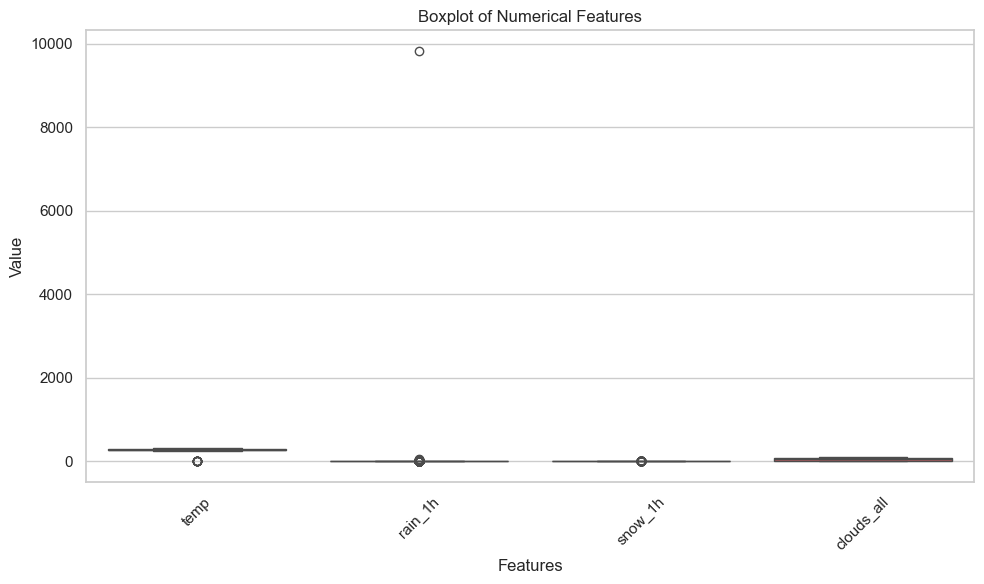

In [37]:
# Check numerical features for outliers

numeric_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all'
]

plt.figure(figsize=(10, 6))

sns.boxplot(data=data[numeric_features])

plt.title('Boxplot of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Count possible outliers using IQR

for feature in numeric_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((data[feature] < lower) | (data[feature] > upper)).sum()
    
    print(feature, ":", count)

temp : 10
rain_1h : 3467
snow_1h : 63
clouds_all : 0


In [39]:
# Extract time features

data['hour'] = data['date_time'].dt.hour
data['day_of_week'] = data['date_time'].dt.dayofweek
data['month'] = data['date_time'].dt.month
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

In [40]:
# Create rush hour feature

data['is_rush_hour'] = data['hour'].isin(
    [7, 8, 9, 16, 17, 18]
).astype(int)

### Feature Engineering — Rush Hour

A new binary feature, `is_rush_hour`, is created from the observation
hour. It identifies common morning and evening commuting periods.

This feature may help the regression models capture recurring traffic
patterns that may not be represented as clearly by the raw weather
variables.

In [41]:
# Separate input features and target

X = data.drop(columns=['traffic_volume'])
y = data['traffic_volume']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48187, 14)
y shape: (48187,)


In [42]:
# Remove raw datetime column

X = X.drop(columns=['date_time'])

In [43]:
# Identify categorical and numerical features

categorical_features = [
    'holiday',
    'weather_main',
    'weather_description'
]

numerical_features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_rush_hour'
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['holiday', 'weather_main', 'weather_description']

Numerical features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour']


<h3>Train-Test Split</h3>

In [44]:
# Create bins for stratified split

target_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates='drop'
)

In [45]:
from sklearn.model_selection import train_test_split

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=target_bins
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (38549, 13)
Test set: (9638, 13)


In [46]:
# Compare target statistics

print("Training target:")
print(y_train.describe())

print("\nTest target:")
print(y_test.describe())

Training target:
count    38549.000000
mean      3258.555734
std       1988.508012
min          0.000000
25%       1187.000000
50%       3374.000000
75%       4930.000000
max       7280.000000
Name: traffic_volume, dtype: float64

Test target:
count    9638.000000
mean     3263.867400
std      1980.825805
min         0.000000
25%      1215.250000
50%      3396.500000
75%      4948.750000
max      7217.000000
Name: traffic_volume, dtype: float64


In [47]:
# Calculate IQR limits from training data

outlier_limits = {}

for feature in numerical_features:
    Q1 = X_train[feature].quantile(0.25)
    Q3 = X_train[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_limits[feature] = (lower, upper)

In [48]:
# Cap extreme values

for feature, (lower, upper) in outlier_limits.items():
    X_train[feature] = X_train[feature].clip(lower, upper)
    X_test[feature] = X_test[feature].clip(lower, upper)

### Outlier Treatment

Potential outliers were identified using the IQR method. Extreme
values in the numerical input features were capped instead of removing
the corresponding observations.

The IQR limits were calculated using only the training data and then
applied to both training and test sets to avoid data leakage.

<h3>Encoding</h3>

In [49]:
from sklearn.preprocessing import OneHotEncoder

# Create encoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [50]:
# Fit encoder on training data

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

<h3>Scaling</h3>

In [51]:
from sklearn.preprocessing import StandardScaler

# Create scaler

scaler = StandardScaler()

In [52]:
# Fit scaler on training data

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

In [53]:
# Combine processed features

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (38549, 70)
Processed test shape: (9638, 70)


In [54]:
# Get encoded feature names

encoded_features = encoder.get_feature_names_out(
    categorical_features
)

final_feature_names = numerical_features + list(encoded_features)

print("Total features:", len(final_feature_names))

Total features: 70


In [55]:
# Create processed DataFrames

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=final_feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=final_feature_names,
    index=X_test.index
)

print(X_train_processed.shape)
print(X_test_processed.shape)

(38549, 70)
(9638, 70)


In [56]:
# Final check

print("Training data:")
print(X_train_processed.head())

print("\nTest data:")
print(X_test_processed.head())

Training data:
           temp  rain_1h  snow_1h  clouds_all      hour  day_of_week  \
42291 -0.388767      0.0      0.0   -1.137436  1.098178    -1.486713   
2774  -0.908179      0.0      0.0    0.657826  1.530221    -0.988393   
46901  0.877495      0.0      0.0    0.657826  0.234094    -0.988393   
6464   0.359658      0.0      0.0    1.042525 -0.197949    -0.988393   
1146  -1.015209      0.0      0.0    1.042525  1.530221    -1.486713   

          month  is_weekend  is_rush_hour  holiday_Christmas Day  \
42291 -1.031210   -0.630165     -0.581374                    0.0   
2774  -1.619877   -0.630165     -0.581374                    0.0   
46901  0.440458   -0.630165     -0.581374                    0.0   
6464  -0.442543   -0.630165     -0.581374                    0.0   
1146   1.323459   -0.630165     -0.581374                    0.0   

       holiday_Columbus Day  holiday_Independence Day  holiday_Labor Day  \
42291                   0.0                       0.0              

In [57]:
# Check for missing values after preprocessing

print("Training missing values:",
      X_train_processed.isnull().sum().sum())

print("Test missing values:",
      X_test_processed.isnull().sum().sum())

Training missing values: 0
Test missing values: 0


## Preprocessing Summary

- Missing values were checked and no missing values were found.
- Duplicate rows were checked and removed if present.
- Numerical features were checked for potential outliers using the IQR method.
- Extreme numerical values were capped using limits calculated from the training data.
- Time-based features were extracted from `date_time`.
- `is_rush_hour` was created as an engineered feature.
- Categorical features were one-hot encoded.
- Numerical features were standardized.
- The dataset was divided into 80% training and 20% testing data.
- Encoders and scalers were fitted only on the training data.

# Regression Models

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. SVR
10. KNN Regressor

In [58]:
# Regression models and evaluation metrics

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [59]:
# Store model results

results = {}

<h3>Algorithm 1 — Linear Regression</h3>

In [60]:
# Linear Regression

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
# Make predictions

linear_pred = linear_model.predict(X_test_processed)

In [62]:
# Evaluate Linear Regression

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression")
print("R2 Score :", linear_r2)
print("RMSE     :", linear_rmse)
print("MAE      :", linear_mae)

Linear Regression
R2 Score : 0.3611829082692197
RMSE     : 1583.1133717723685
MAE      : 1368.055640767527


In [63]:
# Evaluate Linear Regression

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression")
print("R2 Score :", linear_r2)
print("RMSE     :", linear_rmse)
print("MAE      :", linear_mae)

Linear Regression
R2 Score : 0.3611829082692197
RMSE     : 1583.1133717723685
MAE      : 1368.055640767527


<h3>Algorithm 2 — Ridge Regression</h3>

In [64]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_processed,
    y_train
)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [65]:
# Make predictions

ridge_pred = ridge_model.predict(X_test_processed)

In [66]:
# Evaluate Ridge Regression

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge Regression")
print("R2 Score :", ridge_r2)
print("RMSE     :", ridge_rmse)
print("MAE      :", ridge_mae)

Ridge Regression
R2 Score : 0.3611907102719405
RMSE     : 1583.1037043004844
MAE      : 1368.0397790083553


In [67]:
# Save results

results['Ridge Regression'] = {
    'R2': ridge_r2,
    'RMSE': ridge_rmse,
    'MAE': ridge_mae
}

<h3>Algorithm 3 — Lasso Regression</h3>

In [68]:
# Lasso Regression

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_processed,
    y_train
)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [69]:
# Make predictions

lasso_pred = lasso_model.predict(X_test_processed)

In [70]:
# Evaluate Lasso Regression

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)

print("Lasso Regression")
print("R2 Score :", lasso_r2)
print("RMSE     :", lasso_rmse)
print("MAE      :", lasso_mae)

Lasso Regression
R2 Score : 0.36120108927134353
RMSE     : 1583.0908435770987
MAE      : 1368.0764929831162


In [71]:
# Evaluate Lasso Regression

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)

print("Lasso Regression")
print("R2 Score :", lasso_r2)
print("RMSE     :", lasso_rmse)
print("MAE      :", lasso_mae)

Lasso Regression
R2 Score : 0.36120108927134353
RMSE     : 1583.0908435770987
MAE      : 1368.0764929831162


<h3>Algorithm 4 — ElasticNet Regression</h3>

In [72]:
# ElasticNet Regression

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(
    X_train_processed,
    y_train
)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [73]:
# Make predictions

elastic_pred = elastic_model.predict(X_test_processed)

In [74]:
# Evaluate ElasticNet

elastic_r2 = r2_score(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))
elastic_mae = mean_absolute_error(y_test, elastic_pred)

print("ElasticNet Regression")
print("R2 Score :", elastic_r2)
print("RMSE     :", elastic_rmse)
print("MAE      :", elastic_mae)

ElasticNet Regression
R2 Score : 0.3603405344784578
RMSE     : 1584.1568111944011
MAE      : 1370.952795921971


In [75]:
# Save results

results['ElasticNet Regression'] = {
    'R2': elastic_r2,
    'RMSE': elastic_rmse,
    'MAE': elastic_mae
}

<h3>Algorithm 5 — Polynomial Regression</h3>

In [76]:
# Polynomial feature transformation

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [77]:
# Use numerical features for polynomial regression

X_train_poly_base = X_train[numeric_features]
X_test_poly_base = X_test[numeric_features]

print("Training shape:", X_train_poly_base.shape)
print("Test shape:", X_test_poly_base.shape)

Training shape: (38549, 4)
Test shape: (9638, 4)


In [78]:
# Compare polynomial degrees

for degree in [2, 3]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(
        X_train_poly_base
    )

    X_test_poly = poly.transform(
        X_test_poly_base
    )

    poly_model = LinearRegression()

    poly_model.fit(
        X_train_poly,
        y_train
    )

    poly_pred = poly_model.predict(
        X_test_poly
    )

    print("Polynomial Degree:", degree)
    print("Number of features:", X_train_poly.shape[1])
    print("R2 Score:", r2_score(y_test, poly_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
    print("MAE:", mean_absolute_error(y_test, poly_pred))
    print()

Polynomial Degree: 2
Number of features: 14
R2 Score: 0.03703528092125297
RMSE: 1943.6986876783387
MAE: 1692.4186480191872

Polynomial Degree: 3
Number of features: 34
R2 Score: 0.047678927013703576
RMSE: 1932.9269922710284
MAE: 1680.797553197208



### Observation — Polynomial Regression

Polynomial Regression was evaluated using degrees 2 and 3.

The degree-3 model achieved a higher R2 score and lower RMSE and MAE
than the degree-2 model. Therefore, degree 3 was selected for the
Polynomial Regression model.

In [79]:
# Final Polynomial Regression model

poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train_poly_base
)

X_test_poly = poly.transform(
    X_test_poly_base
)

poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

poly_pred = poly_model.predict(
    X_test_poly
)

print("Polynomial Regression")
print("Degree: 3")
print("R2 Score:", r2_score(y_test, poly_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
print("MAE:", mean_absolute_error(y_test, poly_pred))

Polynomial Regression
Degree: 3
R2 Score: 0.047678927013703576
RMSE: 1932.9269922710284
MAE: 1680.797553197208


<h3>Algorithm 6 — Decision Tree Regressor</h3>

In [80]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

In [81]:
# Decision Tree Regression

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train_processed,
    y_train
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [82]:
# Make predictions

tree_pred = tree_model.predict(
    X_test_processed
)

In [83]:
# Evaluate Decision Tree

print("Decision Tree Regressor")
print("R2 Score:", r2_score(y_test, tree_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_pred)))
print("MAE:", mean_absolute_error(y_test, tree_pred))

Decision Tree Regressor
R2 Score: 0.8989347533366444
RMSE: 629.6869222444219
MAE: 319.00311267897905


In [84]:
from sklearn.model_selection import GridSearchCV

# Values for max_depth

tree_params = {
    'max_depth': [5, 10, 15, 20, None]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

tree_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [85]:
# Best parameters

print("Best parameters:")
print(tree_grid.best_params_)

print("\nBest CV R2:")
print(tree_grid.best_score_)

Best parameters:
{'max_depth': 10}

Best CV R2:
0.9352375586848807


In [86]:
# Tuned Decision Tree

best_tree = tree_grid.best_estimator_

tree_tuned_pred = best_tree.predict(
    X_test_processed
)

print("Tuned Decision Tree")
print("R2 Score:", r2_score(y_test, tree_tuned_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_tuned_pred)))
print("MAE:", mean_absolute_error(y_test, tree_tuned_pred))

Tuned Decision Tree
R2 Score: 0.9299518013117689
RMSE: 524.230445181354
MAE: 290.1968958012484


<h3>Algorithm 7 — Random Forest Regressor</h3>

In [87]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

In [88]:
# Random Forest Regression

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [89]:
# Make predictions

forest_pred = forest_model.predict(
    X_test_processed
)

In [90]:
# Evaluate Random Forest

print("Random Forest Regressor")
print("R2 Score:", r2_score(y_test, forest_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, forest_pred)))
print("MAE:", mean_absolute_error(y_test, forest_pred))

Random Forest Regressor
R2 Score: 0.9389193684770509
RMSE: 489.5257177546705
MAE: 264.9735354030178


In [91]:
# Values for n_estimators

forest_params = {
    'n_estimators': [50, 100, 200]
}

forest_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    forest_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

forest_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [92]:
# Best parameters

print("Best parameters:")
print(forest_grid.best_params_)

print("\nBest CV R2:")
print(forest_grid.best_score_)

Best parameters:
{'n_estimators': 200}

Best CV R2:
0.9445283684091865


In [93]:
# Tuned Random Forest

best_forest = forest_grid.best_estimator_

forest_tuned_pred = best_forest.predict(
    X_test_processed
)

print("Tuned Random Forest")
print("R2 Score:", r2_score(y_test, forest_tuned_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, forest_tuned_pred)))
print("MAE:", mean_absolute_error(y_test, forest_tuned_pred))

Tuned Random Forest
R2 Score: 0.9393763201729554
RMSE: 487.69117924433783
MAE: 264.26628394117034


<h3>Algorithm 8 — Gradient Boosting Regressor</h3>

In [94]:
# Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

In [95]:
# Gradient Boosting Regression

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(
    X_train_processed,
    y_train
)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [96]:
# Make predictions

gb_pred = gb_model.predict(
    X_test_processed
)

In [97]:
# Evaluate Gradient Boosting

print("Gradient Boosting Regressor")
print("R2 Score:", r2_score(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("MAE:", mean_absolute_error(y_test, gb_pred))

Gradient Boosting Regressor
R2 Score: 0.9191447096240624
RMSE: 563.2198779063862
MAE: 359.5872146823059


In [98]:
# Values for learning_rate

gb_params = {
    'learning_rate': [0.01, 0.05, 0.1]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(
        random_state=42
    ),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

In [99]:
# Best parameters

print("Best parameters:")
print(gb_grid.best_params_)

print("\nBest CV R2:")
print(gb_grid.best_score_)

Best parameters:
{'learning_rate': 0.1}

Best CV R2:
0.9219646840265975


In [100]:
# Tuned Gradient Boosting

best_gb = gb_grid.best_estimator_

gb_tuned_pred = best_gb.predict(
    X_test_processed
)

print("Tuned Gradient Boosting")
print("R2 Score:", r2_score(y_test, gb_tuned_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_tuned_pred)))
print("MAE:", mean_absolute_error(y_test, gb_tuned_pred))

Tuned Gradient Boosting
R2 Score: 0.9191447096240624
RMSE: 563.2198779063862
MAE: 359.5872146823059


<h3>Algorithm 9 — Support Vector Regressor</h3>

In [101]:
# Support Vector Regressor

from sklearn.svm import SVR

In [102]:
# SVR model

svr_model = SVR(
    C=1.0,
    kernel='rbf'
)

svr_model.fit(
    X_train_processed,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [103]:
# Make predictions

svr_pred = svr_model.predict(
    X_test_processed
)

In [116]:
svr_r2 = r2_score(y_test, svr_pred)

svr_rmse = np.sqrt(
    mean_squared_error(y_test, svr_pred)
)

svr_mae = mean_absolute_error(
    y_test, svr_pred
)

print("SVR Performance")
print("----------------")
print("R² Score :", svr_r2)
print("RMSE     :", svr_rmse)
print("MAE      :", svr_mae)

SVR Performance
----------------
R² Score : 0.35694446788364986
RMSE     : 1588.3565303374253
MAE      : 1394.5838878641823


<h3>Algorithm 10 — K-Nearest Neighbors Regressor</h3>

In [105]:
# KNN Regressor

from sklearn.neighbors import KNeighborsRegressor

In [106]:
# KNN Regression

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [107]:
# Make predictions

knn_pred = knn_model.predict(
    X_test_processed
)

In [108]:
# Evaluate KNN

print("KNN Regressor")
print("R2 Score:", r2_score(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))
print("MAE:", mean_absolute_error(y_test, knn_pred))

KNN Regressor
R2 Score: 0.8360658315710279
RMSE: 801.9706869316702
MAE: 523.7670678564017


In [109]:
# Values for k

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

knn_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter index

In [110]:
# Best KNN parameters

print("Best parameters:")
print(knn_grid.best_params_)

print("\nBest CV R2:")
print(knn_grid.best_score_)

Best parameters:
{'n_neighbors': 5}

Best CV R2:
0.8337352746075617


In [111]:
# Tuned KNN

best_knn = knn_grid.best_estimator_

knn_tuned_pred = best_knn.predict(
    X_test_processed
)

knn_tuned_r2 = r2_score(
    y_test,
    knn_tuned_pred
)

knn_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        knn_tuned_pred
    )
)

knn_tuned_mae = mean_absolute_error(
    y_test,
    knn_tuned_pred
)

print("Tuned KNN")
print("R2 Score:", knn_tuned_r2)
print("RMSE:", knn_tuned_rmse)
print("MAE:", knn_tuned_mae)

Tuned KNN
R2 Score: 0.8360658315710279
RMSE: 801.9706869316702
MAE: 523.7670678564017


<h2>Final Regression Evaluation</h2>

In [112]:
# Final Polynomial Regression model

poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train[numeric_features]
)

X_test_poly = poly.transform(
    X_test[numeric_features]
)

poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

poly_pred = poly_model.predict(
    X_test_poly
)

poly_r2 = r2_score(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_mae = mean_absolute_error(y_test, poly_pred)

print("Polynomial Regression - Degree 3")
print("R2 Score:", poly_r2)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)

Polynomial Regression - Degree 3
R2 Score: 0.047678927013703576
RMSE: 1932.9269922710284
MAE: 1680.797553197208


In [117]:
# Final model results

final_results = {
    'Linear Regression': {
        'R2': linear_r2,
        'RMSE': linear_rmse,
        'MAE': linear_mae
    },

    'Ridge Regression': {
        'R2': ridge_r2,
        'RMSE': ridge_rmse,
        'MAE': ridge_mae
    },

    'Lasso Regression': {
        'R2': lasso_r2,
        'RMSE': lasso_rmse,
        'MAE': lasso_mae
    },

    'ElasticNet Regression': {
        'R2': elastic_r2,
        'RMSE': elastic_rmse,
        'MAE': elastic_mae
    },

    'Polynomial Regression': {
        'R2': poly_r2,
        'RMSE': poly_rmse,
        'MAE': poly_mae
    },

    'Decision Tree Regressor': {
        'R2': r2_score(y_test, tree_tuned_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, tree_tuned_pred)),
        'MAE': mean_absolute_error(y_test, tree_tuned_pred)
    },

    'Random Forest Regressor': {
        'R2': r2_score(y_test, forest_tuned_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, forest_tuned_pred)),
        'MAE': mean_absolute_error(y_test, forest_tuned_pred)
    },

    'Gradient Boosting Regressor': {
        'R2': r2_score(y_test, gb_tuned_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, gb_tuned_pred)),
        'MAE': mean_absolute_error(y_test, gb_tuned_pred)
    },

    'SVR': {
        'R2': svr_r2,
        'RMSE': svr_rmse,
        'MAE': svr_mae
    },

    'KNN Regressor': {
        'R2': knn_tuned_r2,
        'RMSE': knn_tuned_rmse,
        'MAE': knn_tuned_mae
    }
}

In [118]:
# Create final comparison table

regression_results = pd.DataFrame(
    final_results
).T

regression_results = regression_results.sort_values(
    by='R2',
    ascending=False
)

regression_results

,R2,RMSE,MAE
Random Forest Regressor,0.939376,487.691179,264.266284
Decision Tree Regressor,0.929952,524.230445,290.196896
Gradient Boosting Regressor,0.919145,563.219878,359.587215
KNN Regressor,0.836066,801.970687,523.767068
Lasso Regression,0.361201,1583.090844,1368.076493
Ridge Regression,0.361191,1583.103704,1368.039779
Linear Regression,0.361183,1583.113372,1368.055641
ElasticNet Regression,0.360341,1584.156811,1370.952796
SVR,0.356944,1588.356530,1394.583888
Polynomial Regression,0.047679,1932.926992,1680.797553


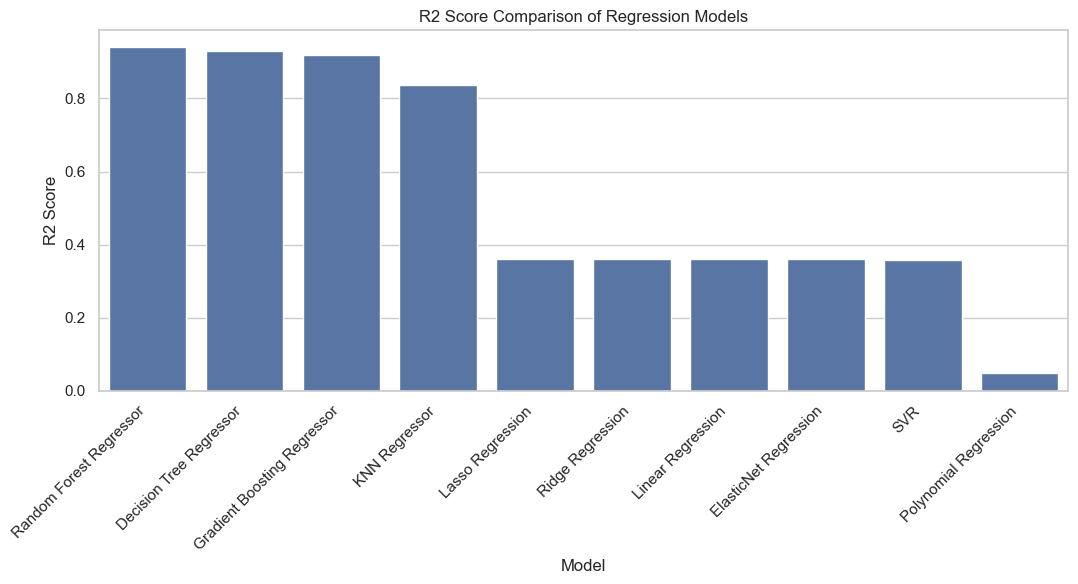

In [119]:
# Compare R2 scores

plt.figure(figsize=(11, 6))

sns.barplot(
    x=regression_results.index,
    y=regression_results['R2']
)

plt.title('R2 Score Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

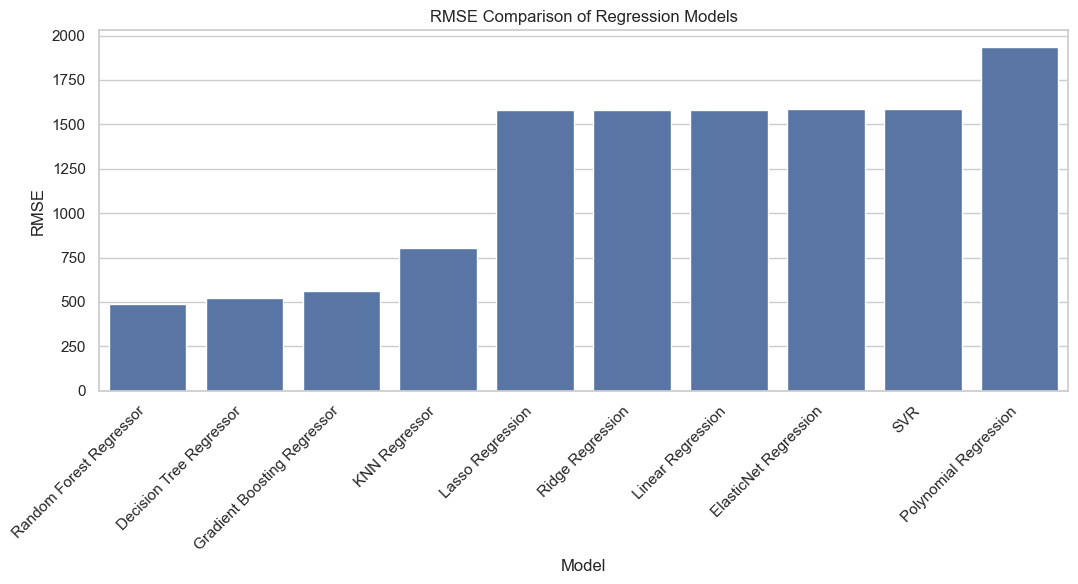

In [120]:
# Compare RMSE scores

plt.figure(figsize=(11, 6))

sns.barplot(
    x=regression_results.index,
    y=regression_results['RMSE']
)

plt.title('RMSE Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

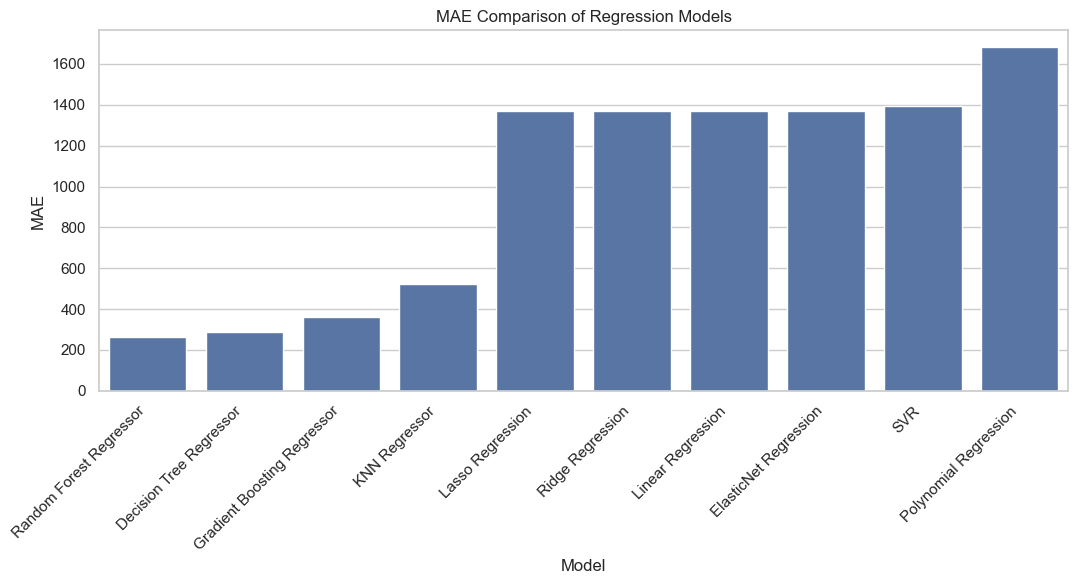

In [121]:
# Compare MAE scores

plt.figure(figsize=(11, 6))

sns.barplot(
    x=regression_results.index,
    y=regression_results['MAE']
)

plt.title('MAE Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [122]:
# Get the two best models

top_two_models = regression_results.head(2)

print("Top two models:")
print(top_two_models)

Top two models:
                               R2        RMSE         MAE
Random Forest Regressor  0.939376  487.691179  264.266284
Decision Tree Regressor  0.929952  524.230445  290.196896


In [138]:
model_objects = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'ElasticNet Regression': elastic_model,
    'Polynomial Regression': poly,
    'Decision Tree Regressor': best_tree,
    'Random Forest Regressor': best_forest,
    'Gradient Boosting Regressor': best_gb,
    'SVR': svr_model,
    'KNN Regressor': best_knn
}

In [139]:
# Cross-validation for the two best models
from sklearn.model_selection import cross_val_score

cv_results = {}

for model_name in top_two_models.index:

    if model_name == 'Polynomial Regression':
        continue

    model = model_objects[model_name]

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    cv_results[model_name] = {
        'Mean CV R2': scores.mean(),
        'Std CV R2': scores.std()
    }

    print(model_name)
    print("CV R2 scores:", scores)
    print("Mean CV R2:", scores.mean())
    print("Std CV R2:", scores.std())
    print()

Random Forest Regressor
CV R2 scores: [0.94921935 0.94348257 0.94352496 0.94305363 0.94336133]
Mean CV R2: 0.9445283684091865
Std CV R2: 0.0023512853262268965

Decision Tree Regressor
CV R2 scores: [0.93843386 0.93666694 0.93472561 0.93226705 0.93409433]
Mean CV R2: 0.9352375586848807
Std CV R2: 0.002128494552613532



In [128]:
from sklearn.pipeline import make_pipeline

# Polynomial Regression pipeline

poly_cv_model = make_pipeline(
    PolynomialFeatures(
        degree=3,
        include_bias=False
    ),
    LinearRegression()
)

poly_cv_scores = cross_val_score(
    poly_cv_model,
    X_train[numeric_features],
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Polynomial Regression")
print("CV R2 scores:", poly_cv_scores)
print("Mean CV R2:", poly_cv_scores.mean())
print("Std CV R2:", poly_cv_scores.std())

Polynomial Regression
CV R2 scores: [0.04997777 0.05362787 0.04816795 0.04509471 0.04879001]
Mean CV R2: 0.04913166188029785
Std CV R2: 0.0027667374872605704


In [140]:
# Best model

best_model_name = regression_results.index[0]

print("Best model:", best_model_name)

Best model: Random Forest Regressor


In [141]:
prediction_objects = {
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'ElasticNet Regression': elastic_pred,
    'Polynomial Regression': poly_pred,
    'Decision Tree Regressor': tree_tuned_pred,
    'Random Forest Regressor': forest_tuned_pred,
    'Gradient Boosting Regressor': gb_tuned_pred,
    'SVR': svr_pred,
    'KNN Regressor': knn_tuned_pred
}

best_predictions = prediction_objects[best_model_name]

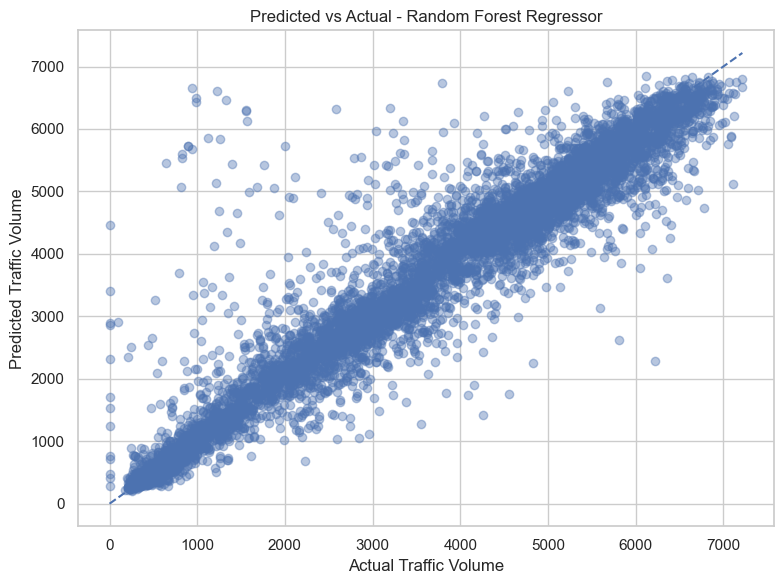

In [142]:
# Predicted vs actual

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title(f'Predicted vs Actual - {best_model_name}')
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.tight_layout()
plt.show()

In [143]:
# Calculate residuals

residuals = y_test - best_predictions

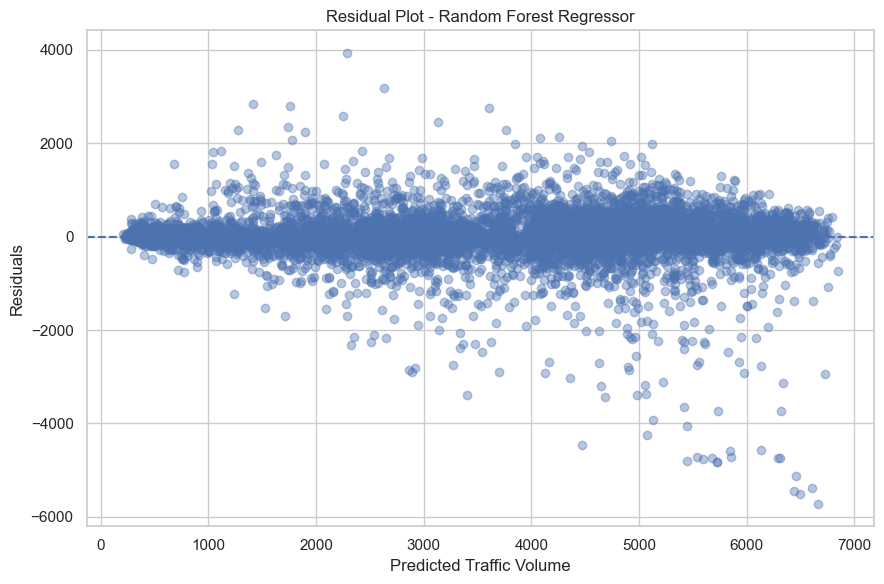

In [144]:
# Residual plot

plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(f'Residual Plot - {best_model_name}')
plt.xlabel('Predicted Traffic Volume')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

In [145]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': best_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,hour,0.823417
5,day_of_week,0.059982
7,is_weekend,0.049597
0,temp,0.032982
6,month,0.010722
8,is_rush_hour,0.005254
3,clouds_all,0.005164
34,weather_description_broken clouds,0.001040
22,weather_main_Clouds,0.001032
51,weather_description_overcast clouds,0.001029


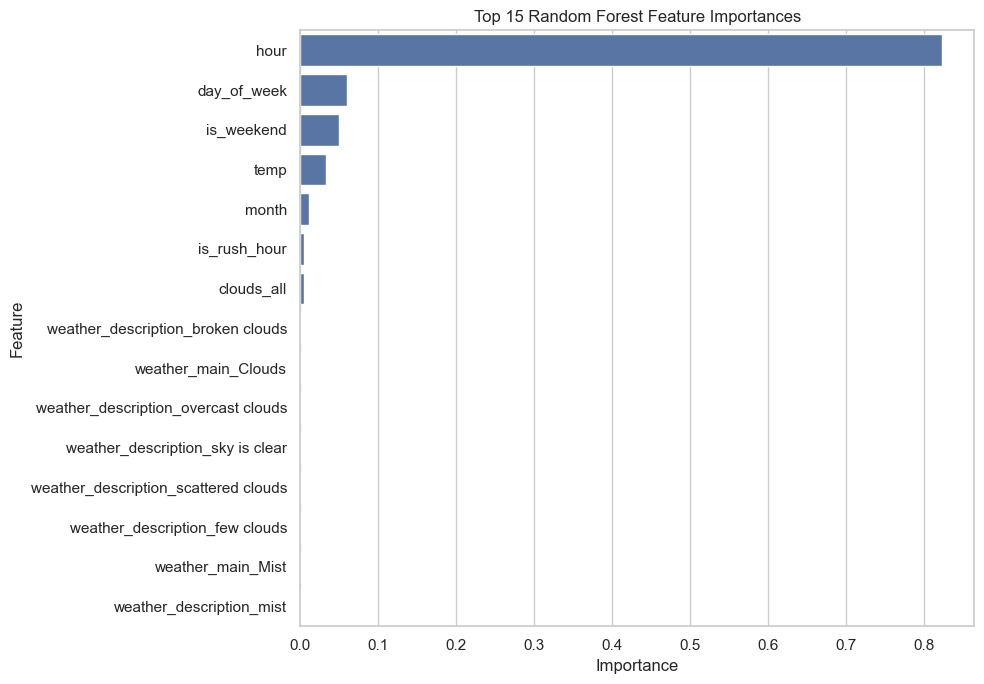

In [146]:
# Plot feature importance

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Regression Track — Final Summary

All 10 required regression algorithms were trained and evaluated on
the same held-out test set.

The models were compared using R2, RMSE and MAE. Hyperparameter
tuning was performed using GridSearchCV for multiple models, and the
two best-performing models were further evaluated using 5-fold
cross-validation.

The final analysis also includes a predicted-vs-actual plot and
residual plot for the best-performing model, along with a feature
importance analysis for a tree-based model.